In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:

X, y = load_iris(return_X_y = True, as_frame = True)
X.head(15)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [4]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
X['target'] =  y
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
X.groupby('target').agg('count')
# 3 категории поровну

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,50,50,50,50
1,50,50,50,50
2,50,50,50,50


Text(0.5, 1.0, 'petal size')

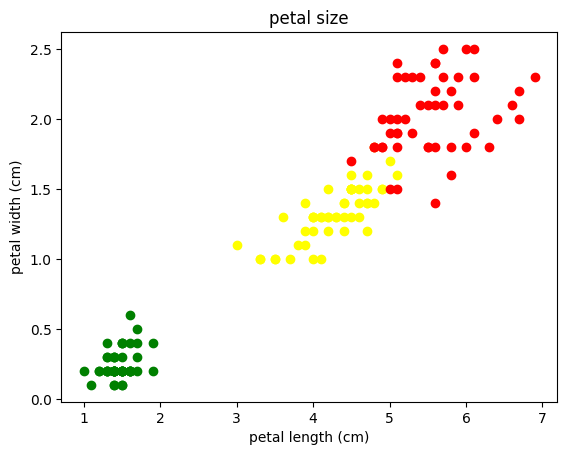

In [8]:
# разделим датафрейм на категории
first_cat = X[X.target == 0]
second_cat = X[X.target == 1]
third_cat = X[X.target == 2]

# построим график распределиения точек по признакам длины и ширины листика
fig, ax = plt.subplots()

ax.scatter(first_cat['petal length (cm)'], first_cat['petal width (cm)'], facecolor="green")
ax.scatter(second_cat['petal length (cm)'], second_cat['petal width (cm)'], facecolor="yellow")
ax.scatter(third_cat['petal length (cm)'], third_cat['petal width (cm)'], facecolor="red")

ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")

ax.set_title('petal size')



In [9]:
# приступим к построению модели логистической регрессии

# Для начала уберем гиперпараметр который не будет использоваться для обучения
X = X.drop(['target'], axis=1)

# Разобьем фрейм на сеты train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# создаем класс модели
logistic_reg = LogisticRegression()

# обучаем используя тренировочный тест
logistic_reg.fit(X_train, y_train)

LogisticRegression()

In [11]:
# Оценим качество модели

y_pred = logistic_reg.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [12]:
y_test = np.array(y_test)
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [14]:
# F1 score

def f1_score_man(y_true, y_pred):
    true_positives = sum(y_true[i] == 1 and y_pred[i] == 1 for i in range(len(y_true)))
    false_positives = sum(y_true[i] == 0 and y_pred[i] == 1 for i in range(len(y_true)))
    false_negatives = sum(y_true[i] == 1 and y_pred[i] == 0 for i in range(len(y_true)))

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)

    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


f1 = f1_score_man(y_test, y_pred)
f1

1.0

In [16]:
#accuracy

def accuracy(y_true, y_pred):
    correct = sum(y_true[i] == y_pred[i] for i in range(len(y_true)))
    acc = correct / len(y_true)
    return acc

acc = accuracy(y_test, y_pred)
acc

1.0

In [ ]:
# Странно но модель идеально точная, похоже из за того что датасет тренировочный